## Prognozowanie ceny akcji
W tym notatniku przedstawiono proces uczenia maszynowego wykorzystanego w celu przewidywania cen akcji.
1. Import danych
2. Analiza danych
3. Czyszczenie danych
4. Inżynieria cech
5. Szkolenie modelu
6. Ocena modelu

### Import bibliotek

In [ ]:
! pip install -q -r ../requirements.txt

In [22]:
#import libraries
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Dropout
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["figure.figsize"] = (14, 7)
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"

### Nieprzewidywalność i wpływ zdarzeń na kurs - przykład notowań DAX20 w czasie pandemii

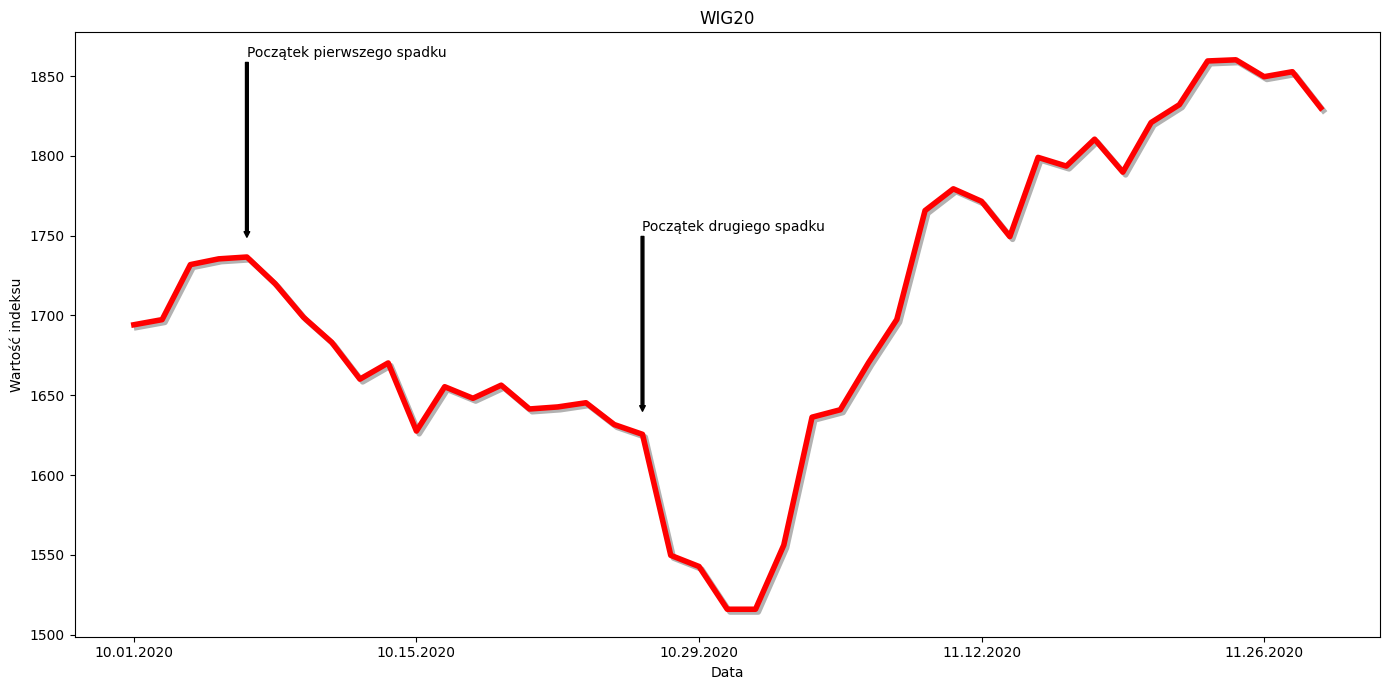

In [23]:
import matplotlib.patheffects as path_effects

fig, ax = plt.subplots(figsize=(14, 7))

dax_dates = [
'11.30.2020',
'11.27.2020',
'11.26.2020',
'11.25.2020',
'11.24.2020',
'11.23.2020',
'11.20.2020',
'11.19.2020',
'11.18.2020',
'11.17.2020',
'11.16.2020',
'11.13.2020',
'11.12.2020',
'11.10.2020',
'11.09.2020',
'11.06.2020',
'11.05.2020',
'11.04.2020',
'11.03.2020',
'11.02.2020',
'11.01.2020',
'10.30.2020',
'10.29.2020',
'10.28.2020',
'10.27.2020',
'10.26.2020',
'10.23.2020',
'10.22.2020',
'10.21.2020',
'10.20.2020',
'10.19.2020',
'10.16.2020',
'10.15.2020',
'10.14.2020',
'10.13.2020',
'10.12.2020',
'10.09.2020',
'10.08.2020',
'10.07.2020',
'10.06.2020',
'10.05.2020',
'10.02.2020',
'10.01.2020',
]

dax_dates.reverse()

ratios = [
1830.04,
1852.69,
1849.57,
1860.15,
1859.42,
1832.04,
1820.85,
1789.79,
1810.43,
1793.56,
1799.02,
1749.41,
1771.49,
1779.34,
1765.71,
1697.49,
1670.43,
1640.94,
1636.28,
1556.14,
1515.97,
1515.97,
1542.76,
1549.74,
1625.54,
1631.66,
1645.32,
1642.7,
1641.42,
1656.34,
1648.11,
1655.36,
1627.59,
1670.26,
1660.12,
1683.21,
1698.91,
1719.91,
1736.61,
1735.45,
1731.85,
1697.39,
1694.18,
]
ratios.reverse()

dax_ratio = {'WIG20': ratios}

data = pd.DataFrame(dax_ratio, index=dax_dates)
spx = data['WIG20']
spx.plot(ax=ax, style='r-', path_effects=[path_effects.SimpleLineShadow(),
                       path_effects.Normal()], linewidth=4)

# 07.10.2020 - ustalenia: Zasada „test 48h” przy noclegach dla osób z obszarów wysokiej incidencji, apel o ograniczenie niekoniecznych podróży, przy przekroczeniu 50 nowych zakażeń / 100 000 mieszkańców / 7 dni kraje związkowe mają wdrażać ukierunkowane lokalne ograniczenia
# 28.10.2020 - ogólnoniemiecki pakiet dodatkowych obostrzeń od 02.11 do końca listopada („Wellenbrecher/lockdown light”)

ax.set_title('WIG20')
ax.annotate(
     'Początek pierwszego spadku',
    xy=(4, 1719 + 30),
    xytext=(4, 1719 + 150),
    arrowprops=dict(facecolor='black', headwidth=4, width=2, headlength=4),
    horizontalalignment='left',
    verticalalignment='top'
)

ax.annotate(
     'Początek drugiego spadku',
    xy=(18, 1610 + 30),
    xytext=(18, 1610 + 150),
    arrowprops=dict(facecolor='black', headwidth=4, width=2, headlength=4),
    horizontalalignment='left',
    verticalalignment='top'
)

ax.set_xlabel('Data')
ax.set_ylabel('Wartość indeksu')

plt.tight_layout()
plt.show()



### Import danych

In [ ]:
dataset = pd.read_csv("../data/google.csv")

### Analiza zbioru danych

In [ ]:
dataset.describe()

In [ ]:
dataset.info()

In [ ]:
dataset.head()

## Inżynieria parametrów

In [ ]:
#normalizacja warości do przedziału 0-1
trainset = dataset.iloc[:, 3:4].values
scaler = MinMaxScaler(feature_range = (0,1))
data_scaled = scaler.fit_transform(trainset)
data_scaled

### Podział zbioru na dane treningowe i dane testowe

In [ ]:
x_train = []
y_train = []
window = 70 #szerokość okna

for i in range(window, 3500):
    x_train.append(data_scaled[i-window:i, 0])
    y_train.append(data_scaled[i,0])
    
x_train, y_train = np.array(x_train), np.array(y_train)

x_test = []
y_test = []
for i in range(3501, 4300):
    x_test.append(data_scaled[i-window:i, 0])
    y_test.append(data_scaled[i,0])
    
x_test, y_test = np.array(x_test), np.array(y_test)

In [ ]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1],1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1],1))

### Utworzenie modelu LSTM

In [ ]:
#zbuduj model sztucznej sieci neuronowej LSTM (long short-term memory)
regressor = Sequential()
regressor.add(LSTM(units = 50,return_sequences = True,input_shape = (x_train.shape[1],1)))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50,return_sequences = True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units = 50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units = 1))
regressor.compile(optimizer = 'adam',loss = 'mean_squared_error')

### Trenowanie modelu

In [ ]:
regressor.fit(x_train, y_train,epochs = 10, batch_size = 32)

### Przewidywanie wartości dla danych testowych

In [ ]:
predicted_price = regressor.predict(x_test)
predicted_price = scaler.inverse_transform(predicted_price)
predicted_price

In [ ]:
# rzeczywisty kurs dla porównania
real_price =  scaler.inverse_transform(y_test.reshape(-1, 1))
real_price

### Porównanie danych rzeczywistych i prognozy

In [ ]:
plt.plot(real_price, color = 'orange', label = 'real price')
plt.plot(predicted_price, color = 'green', label = 'predicted price')
plt.title('Google stock price prediction')
plt.xlabel('time')
plt.ylabel('stock price')
plt.legend()
plt.show()

### Ewaluacja

In [ ]:
# metryki ewaluacji
print(f'RMSE {metrics.mean_squared_error(predicted_price, real_price, squared=False)}')
print(f'MAE {metrics.mean_absolute_error(predicted_price, real_price)}')